In [1]:
import pandas as pd
import glob

# Check individual model file
ind_files = sorted(glob.glob("/projects/retprogression/rgarridogarcia/test_split/predictions_model_*_calibration.csv"))
print("Individual model columns:", pd.read_csv(ind_files[0]).columns.tolist())
print(pd.read_csv(ind_files[0]).head(2))

print()

# Check ensemble file
ens_file = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv"
print("Ensemble columns:", pd.read_csv(ens_file).columns.tolist())
print(pd.read_csv(ens_file).head(2))

Individual model columns: ['image_id', 'original_index', 'true_label', 'predicted_label', 'prob_class_0', 'prob_class_1', 'logit_0', 'logit_1', 'logit_margin', 'correct']
   image_id  original_index  true_label  predicted_label  prob_class_0  \
0    605367               2           0                1      0.009193   
1    605394               4           1                1      0.004319   

   prob_class_1   logit_0   logit_1  logit_margin  correct  
0      0.990807 -3.015799  1.664281       4.68008    False  
1      0.995681 -3.074159  2.366152       5.44031     True  

Ensemble columns: ['id', 'y_true', 'y_prob_pos', 'y_pred', 'n_folds', 'std_prob']
       id  y_true  y_prob_pos  y_pred  n_folds  std_prob
0  605367       0    0.963294       1        5  0.024629
1  605394       1    0.993335       1        5  0.002314


In [2]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import glob
import os
import numpy as np

# ===========================================================
# Load label corrections
# ===========================================================
def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    print("Key type:", type(list(corrections.keys())[0]))
    return corrections


# ===========================================================
# Load predictions from a CSV file
# ===========================================================
def load_predictions(file_path, type_model="single", corrections=None):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values.copy()
        y_prob = df['y_prob_pos'].values.copy()
        id_col = 'id'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values.copy()
        y_prob = df['prob_class_1'].values.copy()
        id_col = 'image_id'
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != y_true)
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"  [{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")

    return y_true, y_prob


# ===========================================================
# Load predictions and invert class labels + probabilities
# ===========================================================
def load_and_invert(file_path, type_model="single", corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true
    y_prob = 1 - y_prob
    return y_true, y_prob


# ===========================================================
# Compute selected metrics
# ===========================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc         = roc_auc_score(y_true, y_prob)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    acc         = accuracy_score(y_true, y_pred)

    return {
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC":         round(auc, 4),
        "F1":          round(f1, 4),
        "Bal_Acc":     round(bal_acc, 4),
        "Accuracy":    round(acc, 4),
        "TP":          int(tp),
        "TN":          int(tn),
        "FP":          int(fp),
        "FN":          int(fn),
    }


# ===========================================================
# Config
# ===========================================================
THRESHOLD   = 0.5
CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_average.csv",
    },
    "test_split_allR": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split_allR",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_allR/ensemble_average.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_allR/ensemble_average.csv",
    },
}

# ===========================================================
# Main loop
# ===========================================================
rows = []

for split_name, cfg in SPLITS.items():
    for subset, ens_file in [("calibration", cfg["ensemble_cal"]),
                             ("validation",  cfg["ensemble_val"])]:

        # --- Individual models ---
        ind_files = sorted(
            f for f in glob.glob(f"{cfg['base']}/predictions_model_*_{subset}.csv")
            if any(f"predictions_model_{i}_" in f for i in range(1, 6))
        )
        for fp in ind_files:
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            model_id = os.path.basename(fp).split("_")[2]
            yt, yp = load_and_invert(fp, type_model="single", corrections=CORRECTIONS)
            rows.append({
                "split":  split_name,
                "subset": subset,
                "model":  f"model_{model_id}",
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })

        # --- Ensemble ---
        if os.path.exists(ens_file):
            yt, yp = load_and_invert(ens_file, type_model="ensemble", corrections=CORRECTIONS)
            rows.append({
                "split":  split_name,
                "subset": subset,
                "model":  "ensemble_avg",
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })
        else:
            print(f"[MISSING ensemble] {ens_file}")

# ===========================================================
# Build dataframe
# ===========================================================
metrics_df = (
    pd.DataFrame(rows)
    .set_index(["split", "subset", "model"])
    .sort_index()
)

metrics_df

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825
  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_average.csv] Labels changed: 9 / 826
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] La

Sensitivity  Specificity     AUC  \
split           subset      model                                            
test_split      calibration ensemble_avg       0.9545       0.9863  0.9958   
                            model_1            0.8182       0.9963  0.9959   
                            model_2            0.9545       0.9726  0.9947   
                            model_3            0.9091       0.9801  0.9933   
                            model_4            0.8182       0.9813  0.9944   
                            model_5            0.9545       0.9851  0.9940   
                validation  ensemble_avg       1.0000       0.9889  0.9981   
                            model_1            0.8824       0.9963  0.9981   
                            model_2            1.0000       0.9790  0.9984   
                            model_3            1.0000       0.9827  0.9978   
                            model_4            1.0000       0.9839  0.9970   
                            model_5            1.0000       0.9864  0.9977   
test_split_allR calibration ensemble_avg       0.8636       0.9900  0.9967   
                            model_1            0.8636       0.9888  0.9954   
                            model_2            0.7727       0.9925  0.9968   
                            model_3            0.8182       0.9925  0.9957   
                            model_4            0.8182       0.9863  0.9946   
                            model_5            0.9091       0.9925  0.9958   
                validation  ensemble_avg       1.0000       0.9901  0.9981   
                            model_1            1.0000       0.9901  0.9978   
                            model_2            1.0000       0.9901  0.9986   
                            model_3            0.9412       0.9889  0.9974   
                            model_4            0.9412       0.9864  0.9978   
                            model_5            1.0000       0.9901  0.9980   

                                              F1  Bal_Acc  Accuracy  TP   TN  \
split           subset      model                                              
test_split      calibration ensemble_avg  0.7778   0.9704    0.9855  21  792   
                            model_1       0.8372   0.9072    0.9915  18  800   
                            model_2       0.6462   0.9636    0.9721  21  781   
                            model_3       0.6897   0.9446    0.9782  20  787   
                            model_4       0.6545   0.8998    0.9770  18  788   
                            model_5       0.7636   0.9698    0.9842  21  791   
                validation  ensemble_avg  0.7907   0.9944    0.9891  17  800   
                            model_1       0.8571   0.9393    0.9939  15  806   
                            model_2       0.6667   0.9895    0.9794  17  792   
                            model_3       0.7083   0.9913    0.9831  17  795   
                            model_4       0.7234   0.9920    0.9843  17  796   
                            model_5       0.7556   0.9932    0.9867  17  798   
test_split_allR calibration ensemble_avg  0.7755   0.9268    0.9867  19  795   
                            model_1       0.7600   0.9262    0.9855  19  794   
                            model_2       0.7556   0.8826    0.9867  17  797   
                            model_3       0.7826   0.9054    0.9879  18  797   
                            model_4       0.7059   0.9022    0.9818  18  792   
                            model_5       0.8333   0.9508    0.9903  20  797   
                validation  ensemble_avg  0.8095   0.9951    0.9903  17  801   
                            model_1       0.8095   0.9951    0.9903  17  801   
                            model_2       0.8095   0.9951    0.9903  17  801   
                            model_3       0.7619   0.9650    0.9879  16  800   
                            model_4       0.7273   0.9638    0.9855  16  798   
             

In [5]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import glob
import os
import numpy as np

# ===========================================================
# Load label corrections
# ===========================================================
def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    return corrections


# ===========================================================
# Load predictions from a CSV file
# ===========================================================
def load_predictions(file_path, type_model="single", corrections=None):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values.copy()
        y_prob = df['y_prob_pos'].values.copy()
        id_col = 'id'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values.copy()
        y_prob = df['prob_class_1'].values.copy()
        id_col = 'image_id'
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != y_true)
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"  [{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")

    return y_true, y_prob


# ===========================================================
# Load predictions and invert class labels + probabilities
# ===========================================================
def load_and_invert(file_path, type_model="single", corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true
    y_prob = 1 - y_prob
    return y_true, y_prob


# ===========================================================
# Compute selected metrics
# ===========================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc         = roc_auc_score(y_true, y_prob)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    acc         = accuracy_score(y_true, y_pred)

    return {
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC":         round(auc, 4),
        "F1":          round(f1, 4),
        "Bal_Acc":     round(bal_acc, 4),
        "Accuracy":    round(acc, 4),
        "TP":          int(tp),
        "TN":          int(tn),
        "FP":          int(fp),
        "FN":          int(fn),
    }


# ===========================================================
# Config
# ===========================================================
THRESHOLD   = 0.5
CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split",
    },
    "test_split_blackcropped": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split_blackcropped",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_blackcropped",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_blackcropped",
    },
    
}

"""test_split_allR": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split_allR",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_allR",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_allR",
    },"""

# ===========================================================
# Helper: get valid ensemble files from a directory
# ===========================================================
def get_ensemble_files(directory):
    files = glob.glob(os.path.join(directory, "ensemble_*.csv"))
    valid = []
    for f in files:
        df = pd.read_csv(f, nrows=1)
        if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
            valid.append(f)
    return sorted(valid)


# ===========================================================
# Main loop
# ===========================================================
rows = []

for split_name, cfg in SPLITS.items():
    suffix = "_allR" if "allR" in split_name else ""
    suffix = "_blackcropped" if "blackcropped" in split_name else ""

    for subset, ens_dir in [("calibration", cfg["ensemble_cal"]),
                            ("validation",  cfg["ensemble_val"])]:

        # --- Individual models ---
        ind_files = sorted(
            f for f in glob.glob(f"{cfg['base']}/predictions_model_*_{subset}.csv")
            if any(f"predictions_model_{i}_" in f for i in range(1, 6))
        )
        for fp in ind_files:
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            model_id = os.path.basename(fp).split("_")[2]
            yt, yp = load_and_invert(fp, type_model="single", corrections=CORRECTIONS)
            rows.append({
                "subset": subset,
                "model":  f"model_{model_id}{suffix}",
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })

        # --- All ensemble files ---
        for fp in get_ensemble_files(ens_dir):
            ens_name = os.path.basename(fp).replace("ensemble_", "").replace(".csv", "")
            yt, yp = load_and_invert(fp, type_model="ensemble", corrections=CORRECTIONS)
            rows.append({
                "subset": subset,
                "model":  f"{ens_name}{suffix}",
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })

# ===========================================================
# Build and display tables
# ===========================================================
df_all = pd.DataFrame(rows)

cal_table  = (df_all[df_all["subset"] == "calibration"]
              .drop(columns="subset")
              .set_index("model")
              .sort_values("Bal_Acc", ascending=False))

val_table  = (df_all[df_all["subset"] == "validation"]
              .drop(columns="subset")
              .set_index("model")
              .sort_values("Bal_Acc", ascending=False))

print("=" * 80)
print("CALIBRATION METRICS")
print("=" * 80)
display(cal_table)

print("\n" + "=" * 80)
print("VALIDATION METRICS")
print("=" * 80)
display(val_table)

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825
  [ensemble_confidence.csv] Labels changed: 11 / 825
  [ensemble_logit.csv] Labels changed: 11 / 825
  [ensemble_majority_60.csv] Labels changed: 11 / 825
  [ensemble_majority_80.csv] Labels changed: 11 / 825
  [ensemble_max_confidence.csv] Labels changed: 11 / 825
  [ensemble_median.csv] Labels changed: 11 / 825
  [ensemble_unanimous.csv] Labels changed: 11 / 825
  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [p

,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
average,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
logit,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
majority_60,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
majority_80,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
unanimous,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
model_5,0.9545,0.9851,0.9940,0.7636,0.9698,0.9842,21,791,12,1
confidence,0.9545,0.9851,0.9956,0.7636,0.9698,0.9842,21,791,12,1
median,0.9545,0.9851,0.9949,0.7636,0.9698,0.9842,21,791,12,1
model_2,0.9545,0.9726,0.9947,0.6462,0.9636,0.9721,21,781,22,1



VALIDATION METRICS


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
majority_60,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
majority_80,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
unanimous,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
max_confidence,1.0000,0.9889,0.9984,0.7907,0.9944,0.9891,17,800,9,0
average,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
confidence,1.0000,0.9889,0.9980,0.7907,0.9944,0.9891,17,800,9,0
logit,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
model_5,1.0000,0.9864,0.9977,0.7556,0.9932,0.9867,17,798,11,0
median,1.0000,0.9839,0.9975,0.7234,0.9920,0.9843,17,796,13,0


In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import glob
import os
import numpy as np

# ===========================================================
# Load label corrections
# ===========================================================
def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    return corrections


# ===========================================================
# Load predictions from a CSV file
# ===========================================================
def load_predictions(file_path, type_model="single", corrections=None):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values.copy()
        y_prob = df['y_prob_pos'].values.copy()
        id_col = 'id'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values.copy()
        y_prob = df['prob_class_1'].values.copy()
        id_col = 'image_id'
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != y_true)
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"  [{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")

    return y_true, y_prob


# ===========================================================
# Load predictions and invert class labels + probabilities
# ===========================================================
def load_and_invert(file_path, type_model="single", corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true
    y_prob = 1 - y_prob
    return y_true, y_prob


# ===========================================================
# Compute selected metrics
# ===========================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc         = roc_auc_score(y_true, y_prob)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    acc         = accuracy_score(y_true, y_pred)

    return {
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC":         round(auc, 4),
        "F1":          round(f1, 4),
        "Bal_Acc":     round(bal_acc, 4),
        "Accuracy":    round(acc, 4),
        "TP":          int(tp),
        "TN":          int(tn),
        "FP":          int(fp),
        "FN":          int(fn),
    }


# ===========================================================
# Helper: get valid ensemble files from a directory
# ===========================================================
def get_ensemble_files(directory):
    files = glob.glob(os.path.join(directory, "ensemble_*.csv"))
    valid = []
    for f in files:
        df = pd.read_csv(f, nrows=1)
        if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
            valid.append(f)
    return sorted(valid)


# ===========================================================
# Helper: sort table — models 1-5 first, then ensembles by Bal_Acc
# ===========================================================
def sort_table(df):
    models    = df[df["model"].str.match(r"^model_\d+$")].sort_values("model")
    ensembles = df[~df["model"].str.match(r"^model_\d+$")].sort_values("Bal_Acc", ascending=False)
    return pd.concat([models, ensembles]).set_index("model")


# ===========================================================
# Config
# ===========================================================
THRESHOLD   = 0.5
CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split",
    },
    "test_split_blackcropped": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split_blackcropped",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_blackcropped",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_blackcropped",
    },
}

# ===========================================================
# Main loop — store rows per (split, subset)
# ===========================================================
# results[split_name][subset] = list of row dicts
results = {split: {"calibration": [], "validation": []} for split in SPLITS}

for split_name, cfg in SPLITS.items():
    for subset, ens_dir in [("calibration", cfg["ensemble_cal"]),
                            ("validation",  cfg["ensemble_val"])]:

        # --- Individual models ---
        ind_files = sorted(
            f for f in glob.glob(f"{cfg['base']}/predictions_model_*_{subset}.csv")
            if any(f"predictions_model_{i}_" in f for i in range(1, 6))
        )
        for fp in ind_files:
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            model_id = os.path.basename(fp).split("_")[2]
            yt, yp = load_and_invert(fp, type_model="single", corrections=CORRECTIONS)
            results[split_name][subset].append({
                "model": f"model_{model_id}",
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })

        # --- All ensemble files ---
        for fp in get_ensemble_files(ens_dir):
            ens_name = os.path.basename(fp).replace("ensemble_", "").replace(".csv", "")
            yt, yp = load_and_invert(fp, type_model="ensemble", corrections=CORRECTIONS)
            results[split_name][subset].append({
                "model": ens_name,
                **compute_all_metrics(yt, yp, threshold=THRESHOLD),
            })

# ===========================================================
# Display — 4 tables: 2 splits × 2 subsets
# ===========================================================
TITLES = {
    "test_split":            "TEST SPLIT",
    "test_split_blackcropped": "TEST SPLIT — BLACKCROPPED",
}

for split_name in SPLITS:
    for subset in ["calibration", "validation"]:
        rows = results[split_name][subset]
        if not rows:
            print(f"[EMPTY] {split_name} / {subset}")
            continue
        table = sort_table(pd.DataFrame(rows))
        print("=" * 80)
        print(f"{TITLES[split_name]}  |  {subset.upper()}")
        print("=" * 80)
        display(table)
        print()

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825
  [ensemble_confidence.csv] Labels changed: 11 / 825
  [ensemble_logit.csv] Labels changed: 11 / 825
  [ensemble_majority_60.csv] Labels changed: 11 / 825
  [ensemble_majority_80.csv] Labels changed: 11 / 825
  [ensemble_max_confidence.csv] Labels changed: 11 / 825
  [ensemble_median.csv] Labels changed: 11 / 825
  [ensemble_unanimous.csv] Labels changed: 11 / 825
  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [p

,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.8182,0.9963,0.9959,0.8372,0.9072,0.9915,18,800,3,4
model_2,0.9545,0.9726,0.9947,0.6462,0.9636,0.9721,21,781,22,1
model_3,0.9091,0.9801,0.9933,0.6897,0.9446,0.9782,20,787,16,2
model_4,0.8182,0.9813,0.9944,0.6545,0.8998,0.9770,18,788,15,4
model_5,0.9545,0.9851,0.9940,0.7636,0.9698,0.9842,21,791,12,1
average,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
logit,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
majority_60,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1
majority_80,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1



TEST SPLIT  |  VALIDATION


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.8824,0.9963,0.9981,0.8571,0.9393,0.9939,15,806,3,2
model_2,1.0000,0.9790,0.9984,0.6667,0.9895,0.9794,17,792,17,0
model_3,1.0000,0.9827,0.9978,0.7083,0.9913,0.9831,17,795,14,0
model_4,1.0000,0.9839,0.9970,0.7234,0.9920,0.9843,17,796,13,0
model_5,1.0000,0.9864,0.9977,0.7556,0.9932,0.9867,17,798,11,0
average,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
confidence,1.0000,0.9889,0.9980,0.7907,0.9944,0.9891,17,800,9,0
logit,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0
majority_60,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0



TEST SPLIT — BLACKCROPPED  |  CALIBRATION


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.9091,0.8705,0.9586,0.2740,0.8898,0.8715,20,699,104,2
model_2,0.9091,0.9128,0.9755,0.3571,0.9110,0.9127,20,733,70,2
model_3,0.8636,0.9452,0.9696,0.4471,0.9044,0.9430,19,759,44,3
model_4,0.9545,0.9016,0.9785,0.3443,0.9281,0.9030,21,724,79,1
model_5,0.8636,0.9788,0.9729,0.6552,0.9212,0.9758,19,786,17,3
confidence,0.9091,0.9191,0.9750,0.3738,0.9141,0.9188,20,738,65,2
median,0.9091,0.9191,0.9765,0.3738,0.9141,0.9188,20,738,65,2
max_confidence,0.9091,0.9141,0.9688,0.3604,0.9116,0.9139,20,734,69,2
average,0.8636,0.9228,0.9767,0.3689,0.8932,0.9212,19,741,62,3



TEST SPLIT — BLACKCROPPED  |  VALIDATION


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.9412,0.8937,0.9786,0.2689,0.9174,0.8947,16,723,86,1
model_2,0.9412,0.9258,0.9888,0.3441,0.9335,0.9262,16,749,60,1
model_3,1.0000,0.9654,0.9963,0.5484,0.9827,0.9661,17,781,28,0
model_4,1.0000,0.9283,0.9918,0.3696,0.9642,0.9298,17,751,58,0
model_5,0.8824,0.9864,0.9956,0.6977,0.9344,0.9843,15,798,11,2
confidence,1.0000,0.9518,0.9943,0.4658,0.9759,0.9528,17,770,39,0
max_confidence,1.0000,0.9506,0.9916,0.4595,0.9753,0.9516,17,769,40,0
average,1.0000,0.9468,0.9952,0.4416,0.9734,0.9479,17,766,43,0
logit,1.0000,0.9468,0.9950,0.4416,0.9734,0.9479,17,766,43,0


In [10]:
# ===========================================================
# CHECK: Do all files share the same sample IDs?
# ===========================================================

def get_ids(file_path):
    df = pd.read_csv(file_path)
    if 'id' in df.columns:
        return set(df['id'].values)
    elif 'image_id' in df.columns:
        return set(df['image_id'].values)
    else:
        raise ValueError(f"No ID column found in {file_path}. Columns: {df.columns.tolist()}")

# Collect all files per subset
all_files = {"calibration": [], "validation": []}

for split_name, cfg in SPLITS.items():
    suffix = "_allR" if "allR" in split_name else ""

    for subset, ens_dir in [("calibration", cfg["ensemble_cal"]),
                            ("validation",  cfg["ensemble_val"])]:

        # Individual models
        ind_files = sorted(
            f for f in glob.glob(f"{cfg['base']}/predictions_model_*_{subset}.csv")
            if any(f"predictions_model_{i}_" in f for i in range(1, 6))
        )
        for fp in ind_files:
            model_id = os.path.basename(fp).split("_")[2]
            all_files[subset].append((f"model_{model_id}{suffix}", fp))

        # Ensembles
        for fp in get_ensemble_files(ens_dir):
            ens_name = os.path.basename(fp).replace("ensemble_", "").replace(".csv", "")
            all_files[subset].append((f"{ens_name}{suffix}", fp))

# Compare IDs
for subset, file_list in all_files.items():
    print("=" * 80)
    print(f"SUBSET: {subset.upper()}  —  {len(file_list)} files")
    print("=" * 80)

    id_sets = {name: get_ids(fp) for name, fp in file_list}
    all_ids = list(id_sets.values())

    # Reference = first file
    ref_name, ref_ids = list(id_sets.items())[0]
    print(f"Reference: {ref_name}  ({len(ref_ids)} IDs)\n")

    all_match = True
    for name, ids in id_sets.items():
        n        = len(ids)
        only_ref = ref_ids - ids      # in reference but not this file
        only_cur = ids - ref_ids      # in this file but not reference
        match    = "✓" if not only_ref and not only_cur else "✗"
        if only_ref or only_cur:
            all_match = False
        print(f"  {match}  {name:<40}  N={n}  |  missing_from_this={len(only_ref)}  extra_in_this={len(only_cur)}")

    if all_match:
        print(f"\n  ✓ All {len(file_list)} files share exactly the same IDs.")
    else:
        print(f"\n  ✗ ID mismatch detected — see above.")

        # Show the actual mismatched IDs for easy debugging
        for name, ids in id_sets.items():
            only_ref = ref_ids - ids
            only_cur = ids - ref_ids
            if only_ref:
                print(f"\n    IDs in {ref_name} but NOT in {name}:\n    {sorted(only_ref)}")
            if only_cur:
                print(f"\n    IDs in {name} but NOT in {ref_name}:\n    {sorted(only_cur)}")
    print()

SUBSET: CALIBRATION  —  26 files
Reference: model_1  (825 IDs)

  ✓  model_1                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  model_2                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  model_3                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  model_4                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  model_5                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  average                                   N=825  |  missing_from_this=0  extra_in_this=0
  ✓  confidence                                N=825  |  missing_from_this=0  extra_in_this=0
  ✓  logit                                     N=825  |  missing_from_this=0  extra_in_this=0
  ✓  majority_60                               N=825  |  missing_from_this=0  extra_in_this=0
  ✓  majority_80                               N=825  |  missing_from_this=0  extra_in_thi

### Single Experiment

In [3]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import glob
import os
import numpy as np

# ===========================================================
# Load label corrections
# ===========================================================
def load_corrections(corrections_path):
    df = pd.read_csv(corrections_path)
    label_map = {'G': 1, 'U': 0}
    df['Id'] = df['Id'].str.replace('.jpg', '', regex=False).str.strip()
    corrections = dict(zip(df['Id'].astype(int), df['New label'].map(label_map)))
    print("Sample correction keys:", list(corrections.keys())[:5])
    print("Key type:", type(list(corrections.keys())[0]))
    return corrections


# ===========================================================
# Load predictions from a CSV file
# ===========================================================
def load_predictions(file_path, type_model="single", corrections=None):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        y_true = df['y_true'].values.copy()
        y_prob = df['y_prob_pos'].values.copy()
        id_col = 'id'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        y_true = df['true_label'].values.copy()
        y_prob = df['prob_class_1'].values.copy()
        id_col = 'image_id'
    else:
        raise ValueError(f"Unknown column format in {file_path}. Columns: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != y_true)
        n_changed = mask.sum()
        y_true[mask] = corrected[mask].astype(y_true.dtype)
        print(f"  [{os.path.basename(file_path)}] Labels changed: {n_changed} / {len(y_true)}")

    return y_true, y_prob


# ===========================================================
# Load predictions and invert class labels + probabilities
# ===========================================================
def load_and_invert(file_path, type_model="single", corrections=None):
    y_true, y_prob = load_predictions(file_path, type_model=type_model, corrections=corrections)
    y_true = 1 - y_true
    y_prob = 1 - y_prob
    return y_true, y_prob


# ===========================================================
# Compute selected metrics
# ===========================================================
def compute_all_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    auc         = roc_auc_score(y_true, y_prob)
    f1          = f1_score(y_true, y_pred, zero_division=0)
    bal_acc     = balanced_accuracy_score(y_true, y_pred)
    acc         = accuracy_score(y_true, y_pred)

    return {
        "Sensitivity": round(sensitivity, 4),
        "Specificity": round(specificity, 4),
        "AUC":         round(auc, 4),
        "F1":          round(f1, 4),
        "Bal_Acc":     round(bal_acc, 4),
        "Accuracy":    round(acc, 4),
        "TP":          int(tp),
        "TN":          int(tn),
        "FP":          int(fp),
        "FN":          int(fn),
    }



In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np

# ===========================================================
# Config - pick your experiment here
# ===========================================================
SPLIT_NAME  = "test_split_allR"   # or "test_split"
SUBSET      = "validation"         # or "calibration"
THRESHOLD   = 0.5

BASE_DIR    = "/projects/retprogression/rgarridogarcia/test_split_rerun5k"
ENSEMBLE    = "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_rerun5k/ensemble_average.csv"
CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

# ===========================================================
# Run
# ===========================================================
rows = []

for i in range(1, 6):
    fp = f"{BASE_DIR}/predictions_model_{i}_{SUBSET}.csv"
    if not os.path.exists(fp):
        print(f"[MISSING] {fp}")
        continue
    yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
    rows.append({"model": f"model_{i}", **compute_all_metrics(yt, yp, THRESHOLD)})

if os.path.exists(ENSEMBLE):
    yt, yp = load_and_invert(ENSEMBLE, corrections=CORRECTIONS)
    rows.append({"model": "ensemble_avg", **compute_all_metrics(yt, yp, THRESHOLD)})

pd.DataFrame(rows).set_index("model")

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_average.csv] Labels changed: 9 / 826


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.8824,0.9963,0.9981,0.8571,0.9393,0.9939,15,806,3,2
model_2,1.0000,0.9790,0.9984,0.6667,0.9895,0.9794,17,792,17,0
model_3,1.0000,0.9827,0.9978,0.7083,0.9913,0.9831,17,795,14,0
model_4,1.0000,0.9839,0.9970,0.7234,0.9920,0.9843,17,796,13,0
model_5,1.0000,0.9864,0.9977,0.7556,0.9932,0.9867,17,798,11,0
ensemble_avg,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0


### Indian test

In [8]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import os

# ===========================================================
# Config
# ===========================================================
THRESHOLD   = 0.5
BASE_DIR    = "/projects/retprogression/rgarridogarcia/estenda-ihs-test-set"
ENSEMBLE_DIR = "/projects/retprogression/rgarridogarcia/ensemble/estenda-ihs-test-set"
CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

ENSEMBLE_FILES = {
    "ensemble_average":        f"{ENSEMBLE_DIR}/ensemble_average.csv",
    "ensemble_logit":          f"{ENSEMBLE_DIR}/ensemble_logit.csv",
    "ensemble_median":         f"{ENSEMBLE_DIR}/ensemble_median.csv",
    "ensemble_confidence":     f"{ENSEMBLE_DIR}/ensemble_confidence.csv",
    "ensemble_max_confidence": f"{ENSEMBLE_DIR}/ensemble_max_confidence.csv",
    "ensemble_majority_60":    f"{ENSEMBLE_DIR}/ensemble_majority_60.csv",
    "ensemble_majority_80":    f"{ENSEMBLE_DIR}/ensemble_majority_80.csv",
    "ensemble_unanimous":      f"{ENSEMBLE_DIR}/ensemble_unanimous.csv",
}

# ===========================================================
# Run
# ===========================================================
rows = []

# Individual models
for i in range(1, 6):
    fp = f"{BASE_DIR}/cropped1024_cropped_centered_wt_allR_{i}/predictions_best_balanced_acc_model.csv"
    if not os.path.exists(fp):
        print(f"[MISSING] {fp}")
        continue
    yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
    rows.append({"model": f"model_{i}", **compute_all_metrics(yt, yp, THRESHOLD)})

# All ensembles
for ens_name, ens_path in ENSEMBLE_FILES.items():
    if os.path.exists(ens_path):
        yt, yp = load_and_invert(ens_path, corrections=CORRECTIONS)
        rows.append({"model": ens_name, **compute_all_metrics(yt, yp, THRESHOLD)})
    else:
        print(f"[MISSING ensemble] {ens_path}")

pd.DataFrame(rows).set_index("model")

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
  [ensemble_average.csv] Labels changed: 0 / 984
  [ensemble_logit.csv] Labels changed: 0 / 984
  [ensemble_median.csv] Labels changed: 0 / 984
  [ensemble_confidence.csv] Labels changed: 0 / 984
  [ensemble_max_confidence.csv] Labels changed: 0 / 984
  [ensemble_majority_60.csv] Labels changed: 0 / 984
  [ensemble_majority_80.csv] Labels changed: 0 / 984
  [ensemble_unanimous.csv] Labels changed: 0 / 984


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.3113,0.9976,0.8989,0.4700,0.6544,0.8923,47,831,2,104
model_2,0.6093,0.9652,0.8925,0.6765,0.7872,0.9106,92,804,29,59
model_3,0.5232,0.9724,0.9072,0.6245,0.7478,0.9035,79,810,23,72
model_4,0.4371,0.9880,0.8999,0.5815,0.7125,0.9035,66,823,10,85
model_5,0.4768,0.9868,0.9016,0.6154,0.7318,0.9085,72,822,11,79
ensemble_average,0.4702,0.9868,0.9042,0.6094,0.7285,0.9075,71,822,11,80
ensemble_logit,0.4702,0.9868,0.9041,0.6094,0.7285,0.9075,71,822,11,80
ensemble_median,0.4768,0.9868,0.9020,0.6154,0.7318,0.9085,72,822,11,79
ensemble_confidence,0.4768,0.9868,0.9033,0.6154,0.7318,0.9085,72,822,11,79


In [13]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import os

# ===========================================================
# Config
# ===========================================================
THRESHOLD    = 0.5
BASE_DIR     = "/projects/retprogression/rgarridogarcia/estenda-ihs-test-set"
ENSEMBLE_DIR = "/projects/retprogression/rgarridogarcia/ensemble/estenda-ihs-test-set"
CORRECTIONS  = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")
OUTPUT_DIR = "/projects/retprogression"

ENSEMBLE_FILES = {
    "ensemble_average":        f"{ENSEMBLE_DIR}/ensemble_average.csv",
    "ensemble_logit":          f"{ENSEMBLE_DIR}/ensemble_logit.csv",
    "ensemble_median":         f"{ENSEMBLE_DIR}/ensemble_median.csv",
    "ensemble_confidence":     f"{ENSEMBLE_DIR}/ensemble_confidence.csv",
    "ensemble_max_confidence": f"{ENSEMBLE_DIR}/ensemble_max_confidence.csv",
    "ensemble_majority_60":    f"{ENSEMBLE_DIR}/ensemble_majority_60.csv",
    "ensemble_majority_80":    f"{ENSEMBLE_DIR}/ensemble_majority_80.csv",
    "ensemble_unanimous":      f"{ENSEMBLE_DIR}/ensemble_unanimous.csv",
}

# ===========================================================
# Helper to load predictions as a DataFrame with ID, y_true, y_pred, y_prob
# ===========================================================
def load_predictions_df(file_path, corrections, threshold=0.5):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        id_col, true_col, prob_col = 'id', 'y_true', 'y_prob_pos'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        id_col, true_col, prob_col = 'image_id', 'true_label', 'prob_class_1'
    else:
        raise ValueError(f"Unknown columns in {file_path}: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != df[true_col].values)
        df.loc[mask, true_col] = corrected[mask].astype(df[true_col].dtype)

    # Invert
    df['y_true_inv'] = 1 - df[true_col]
    df['y_prob_inv'] = 1 - df[prob_col]
    df['y_pred_inv'] = (df['y_prob_inv'] >= threshold).astype(int)

    return df[[id_col, 'y_true_inv', 'y_pred_inv', 'y_prob_inv']].rename(columns={
        id_col:       'ID',
        'y_true_inv': 'y_true',
        'y_pred_inv': 'y_pred',
        'y_prob_inv': 'y_prob',
    })

# ===========================================================
# Build metrics table + wide predictions table
# ===========================================================
metrics_rows  = []
pred_dfs      = {}   # {model_name: df with ID, y_pred, y_prob}

# Individual models
for i in range(1, 6):
    fp = f"{BASE_DIR}/cropped1024_cropped_centered_wt_allR_{i}/predictions_best_balanced_acc_model.csv"
    if not os.path.exists(fp):
        print(f"[MISSING] {fp}")
        continue
    name = f"model_{i}"
    df   = load_predictions_df(fp, CORRECTIONS, THRESHOLD)
    pred_dfs[name] = df
    yt, yp = df['y_true'].values, df['y_prob'].values
    metrics_rows.append({"model": name, **compute_all_metrics(yt, yp, THRESHOLD)})

# Ensembles
for ens_name, ens_path in ENSEMBLE_FILES.items():
    if not os.path.exists(ens_path):
        print(f"[MISSING ensemble] {ens_path}")
        continue
    df   = load_predictions_df(ens_path, CORRECTIONS, THRESHOLD)
    pred_dfs[ens_name] = df
    yt, yp = df['y_true'].values, df['y_prob'].values
    metrics_rows.append({"model": ens_name, **compute_all_metrics(yt, yp, THRESHOLD)})

# ===========================================================
# Metrics table
# ===========================================================
metrics_df = pd.DataFrame(metrics_rows).set_index("model")
display(metrics_df)

# ===========================================================
# Wide predictions table: ID | y_true | model_1_pred | model_1_prob | ...
# ===========================================================
# Start with ID + y_true from first available model
first_df = next(iter(pred_dfs.values()))[['ID', 'y_true']]
wide_df  = first_df.copy()

for name, df in pred_dfs.items():
    wide_df = wide_df.merge(
        df[['ID', 'y_pred', 'y_prob']].rename(columns={
            'y_pred': f'{name}_pred',
            'y_prob': f'{name}_prob',
        }),
        on='ID', how='left'
    )

# Save
out_path = f"{OUTPUT_DIR}/estenda-ihs-test-set_ungradable_predictions.csv"
wide_df.to_csv(out_path, index=False)
print(f"Saved wide predictions to {out_path}")
display(wide_df.head())

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.3113,0.9976,0.8989,0.4700,0.6544,0.8923,47,831,2,104
model_2,0.6093,0.9652,0.8925,0.6765,0.7872,0.9106,92,804,29,59
model_3,0.5232,0.9724,0.9072,0.6245,0.7478,0.9035,79,810,23,72
model_4,0.4371,0.9880,0.8999,0.5815,0.7125,0.9035,66,823,10,85
model_5,0.4768,0.9868,0.9016,0.6154,0.7318,0.9085,72,822,11,79
ensemble_average,0.4702,0.9868,0.9042,0.6094,0.7285,0.9075,71,822,11,80
ensemble_logit,0.4702,0.9868,0.9041,0.6094,0.7285,0.9075,71,822,11,80
ensemble_median,0.4768,0.9868,0.9020,0.6154,0.7318,0.9085,72,822,11,79
ensemble_confidence,0.4768,0.9868,0.9033,0.6154,0.7318,0.9085,72,822,11,79


Saved wide predictions to /projects/retprogression/estenda-ihs-test-set_ungradable_predictions.csv


,ID,y_true,model_1_pred,model_1_prob,model_2_pred,model_2_prob,model_3_pred,model_3_prob,model_4_pred,model_4_prob,...,ensemble_confidence_pred,ensemble_confidence_prob,ensemble_max_confidence_pred,ensemble_max_confidence_prob,ensemble_majority_60_pred,ensemble_majority_60_prob,ensemble_majority_80_pred,ensemble_majority_80_prob,ensemble_unanimous_pred,ensemble_unanimous_prob
0,2.16.840.1.114209.10.1.21.26.20260326080407960...,0,0,0.013724,0,0.029030,0,0.025396,0,0.003616,...,0,0.017203,0,0.003616,0,0.017372,0,0.017372,0,0.017372
1,2.16.840.1.114209.10.1.21.26.20260326080529425...,0,0,0.023619,0,0.074356,0,0.101327,0,0.015173,...,0,0.057290,0,0.015173,0,0.059967,0,0.059967,0,0.059967
2,2.16.840.1.114209.10.1.21.26.20260326080553784...,0,0,0.016578,0,0.115137,0,0.080461,0,0.008287,...,0,0.048489,0,0.008287,0,0.052108,0,0.052108,0,0.052108
3,2.16.840.1.114209.10.1.21.26.20260326080617171...,0,0,0.028186,0,0.082871,0,0.111876,0,0.016540,...,0,0.062925,0,0.016540,0,0.066102,0,0.066102,0,0.066102
4,2.16.840.1.114209.10.1.21.26.20260326081546512...,0,0,0.008701,0,0.022619,0,0.010538,0,0.004402,...,0,0.010874,0,0.004402,0,0.010951,0,0.010951,0,0.010951


In [24]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import os

# ===========================================================
# Config
# ===========================================================
THRESHOLD    = 0.5
BASE_DIR     = "/projects/retprogression/rgarridogarcia/estenda-ihs-test-set"
ENSEMBLE_DIR = "/projects/retprogression/rgarridogarcia/ensemble/estenda-ihs-test-set"
CORRECTIONS  = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

ENSEMBLE_FILES = {
    "ensemble_average":        f"{ENSEMBLE_DIR}/ensemble_average.csv",
    "ensemble_logit":          f"{ENSEMBLE_DIR}/ensemble_logit.csv",
    "ensemble_median":         f"{ENSEMBLE_DIR}/ensemble_median.csv",
    "ensemble_confidence":     f"{ENSEMBLE_DIR}/ensemble_confidence.csv",
    "ensemble_max_confidence": f"{ENSEMBLE_DIR}/ensemble_max_confidence.csv",
    "ensemble_majority_60":    f"{ENSEMBLE_DIR}/ensemble_majority_60.csv",
    "ensemble_majority_80":    f"{ENSEMBLE_DIR}/ensemble_majority_80.csv",
    "ensemble_unanimous":      f"{ENSEMBLE_DIR}/ensemble_unanimous.csv",
}

# ===========================================================
# Helper to load predictions as a DataFrame with ID, y_true, y_pred, y_prob
# ===========================================================
def load_predictions_df(file_path, corrections, threshold=0.5):
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        id_col, true_col, prob_col = 'id', 'y_true', 'y_prob_pos'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        id_col, true_col, prob_col = 'image_id', 'true_label', 'prob_class_1'
    else:
        raise ValueError(f"Unknown columns in {file_path}: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != df[true_col].values)
        df.loc[mask, true_col] = corrected[mask].astype(df[true_col].dtype)

    # Invert
    df['y_true_inv'] = 1 - df[true_col]
    df['y_prob_inv'] = 1 - df[prob_col]
    df['y_pred_inv'] = (df['y_prob_inv'] >= threshold).astype(int)

    return df[[id_col, 'y_true_inv', 'y_pred_inv', 'y_prob_inv']].rename(columns={
        id_col:       'ID',
        'y_true_inv': 'y_true',
        'y_pred_inv': 'y_pred',
        'y_prob_inv': 'y_prob',
    })

# ===========================================================
# Build metrics table + wide predictions table
# ===========================================================
metrics_rows  = []
pred_dfs      = {}   # {model_name: df with ID, y_pred, y_prob}

# Individual models
for i in range(1, 6):
    fp = f"{BASE_DIR}/cropped1024_cropped_centered_wt_allR_{i}/predictions_best_balanced_acc_model.csv"
    if not os.path.exists(fp):
        print(f"[MISSING] {fp}")
        continue
    name = f"model_{i}"
    df   = load_predictions_df(fp, CORRECTIONS, THRESHOLD)
    yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
    print(yp[:10])
    print(f"min: {yp.min():.4f}, max: {yp.max():.4f}")
    pred_dfs[name] = df
    yt, yp = df['y_true'].values, df['y_prob'].values
    metrics_rows.append({"model": name, **compute_all_metrics(yt, yp, THRESHOLD)})

# Ensembles
for ens_name, ens_path in ENSEMBLE_FILES.items():
    if not os.path.exists(ens_path):
        print(f"[MISSING ensemble] {ens_path}")
        continue
    df   = load_predictions_df(ens_path, CORRECTIONS, THRESHOLD)
    pred_dfs[ens_name] = df
    yt, yp = df['y_true'].values, df['y_prob'].values
    metrics_rows.append({"model": ens_name, **compute_all_metrics(yt, yp, THRESHOLD)})

# ===========================================================
# Metrics table
# ===========================================================
metrics_df = pd.DataFrame(metrics_rows).set_index("model")
display(metrics_df)

# ===========================================================
# Wide predictions table: ID | y_true | model_1_pred | model_1_prob | ...
# ===========================================================
# Start with ID + y_true from first available model
first_df = next(iter(pred_dfs.values()))[['ID', 'y_true']]
wide_df  = first_df.copy()

for name, df in pred_dfs.items():
    wide_df = wide_df.merge(
        df[['ID', 'y_pred', 'y_prob']].rename(columns={
            'y_pred': f'{name}_pred',
            'y_prob': f'{name}_prob',
        }),
        on='ID', how='left'
    )

# Save
out_path = f"{ENSEMBLE_DIR}/all_predictions_wide.csv"
wide_df.to_csv(out_path, index=False)
print(f"Saved wide predictions to {out_path}")
display(wide_df.head())

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
[0.01372421 0.02361906 0.01657772 0.02818626 0.00870126 0.0102998
 0.01396698 0.01039845 0.00389045 0.00451249]
min: 0.0017, max: 0.9390
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
[0.02902997 0.07435632 0.11513668 0.08287096 0.02261853 0.03342873
 0.03196967 0.02960229 0.00975502 0.01266539]
min: 0.0022, max: 0.9960
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
[0.02539563 0.10132682 0.08046144 0.11187643 0.0105384  0.02359849
 0.02171683 0.01953745 0.01454788 0.011702  ]
min: 0.0027, max: 0.9915
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
[0.00361645 0.01517344 0.00828671 0.01654047 0.00440174 0.0050903
 0.0061987  0.00635481 0.00383002 0.00311583]
min: 0.0006, max: 0.9934
  [predictions_best_balanced_acc_model.csv] Labels changed: 0 / 984
[0.01509285 0.0853574

,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.3113,0.9976,0.8989,0.4700,0.6544,0.8923,47,831,2,104
model_2,0.6093,0.9652,0.8925,0.6765,0.7872,0.9106,92,804,29,59
model_3,0.5232,0.9724,0.9072,0.6245,0.7478,0.9035,79,810,23,72
model_4,0.4371,0.9880,0.8999,0.5815,0.7125,0.9035,66,823,10,85
model_5,0.4768,0.9868,0.9016,0.6154,0.7318,0.9085,72,822,11,79
ensemble_average,0.4702,0.9868,0.9042,0.6094,0.7285,0.9075,71,822,11,80
ensemble_logit,0.4702,0.9868,0.9041,0.6094,0.7285,0.9075,71,822,11,80
ensemble_median,0.4768,0.9868,0.9020,0.6154,0.7318,0.9085,72,822,11,79
ensemble_confidence,0.4768,0.9868,0.9033,0.6154,0.7318,0.9085,72,822,11,79


Saved wide predictions to /projects/retprogression/rgarridogarcia/ensemble/estenda-ihs-test-set/all_predictions_wide.csv


,ID,y_true,model_1_pred,model_1_prob,model_2_pred,model_2_prob,model_3_pred,model_3_prob,model_4_pred,model_4_prob,...,ensemble_confidence_pred,ensemble_confidence_prob,ensemble_max_confidence_pred,ensemble_max_confidence_prob,ensemble_majority_60_pred,ensemble_majority_60_prob,ensemble_majority_80_pred,ensemble_majority_80_prob,ensemble_unanimous_pred,ensemble_unanimous_prob
0,2.16.840.1.114209.10.1.21.26.20260326080407960...,0,0,0.013724,0,0.029030,0,0.025396,0,0.003616,...,0,0.017203,0,0.003616,0,0.017372,0,0.017372,0,0.017372
1,2.16.840.1.114209.10.1.21.26.20260326080529425...,0,0,0.023619,0,0.074356,0,0.101327,0,0.015173,...,0,0.057290,0,0.015173,0,0.059967,0,0.059967,0,0.059967
2,2.16.840.1.114209.10.1.21.26.20260326080553784...,0,0,0.016578,0,0.115137,0,0.080461,0,0.008287,...,0,0.048489,0,0.008287,0,0.052108,0,0.052108,0,0.052108
3,2.16.840.1.114209.10.1.21.26.20260326080617171...,0,0,0.028186,0,0.082871,0,0.111876,0,0.016540,...,0,0.062925,0,0.016540,0,0.066102,0,0.066102,0,0.066102
4,2.16.840.1.114209.10.1.21.26.20260326081546512...,0,0,0.008701,0,0.022619,0,0.010538,0,0.004402,...,0,0.010874,0,0.004402,0,0.010951,0,0.010951,0,0.010951


In [15]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import os
import shutil

# ===========================================================
# Config
# ===========================================================
THRESHOLD    = 0.5
BASE_DIR     = "/projects/retprogression/rgarridogarcia/estenda-ihs-test-set"
ENSEMBLE_DIR = "/projects/retprogression/rgarridogarcia/ensemble/estenda-ihs-test-set"
IMAGES_DIR   = "/projects/retprogression/estenda-ihs-test-set_centered_wt"
OUTPUT_DIR   = "/projects/retprogression/ungradable_estenda-ihs-testset_centered_wt"
CORRECTIONS  = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

ENSEMBLE_FILES = {
    "ensemble_average":        f"{ENSEMBLE_DIR}/ensemble_average.csv",
    "ensemble_logit":          f"{ENSEMBLE_DIR}/ensemble_logit.csv",
    "ensemble_median":         f"{ENSEMBLE_DIR}/ensemble_median.csv",
    "ensemble_confidence":     f"{ENSEMBLE_DIR}/ensemble_confidence.csv",
    "ensemble_max_confidence": f"{ENSEMBLE_DIR}/ensemble_max_confidence.csv",
    "ensemble_majority_60":    f"{ENSEMBLE_DIR}/ensemble_majority_60.csv",
    "ensemble_majority_80":    f"{ENSEMBLE_DIR}/ensemble_majority_80.csv",
    "ensemble_unanimous":      f"{ENSEMBLE_DIR}/ensemble_unanimous.csv",
}

# ===========================================================
# Collect FP/FN per model and ensemble
# ===========================================================
model_fps    = {}
model_fns    = {}
ensemble_fps = {}
ensemble_fns = {}

def get_fp_fn(file_path, corrections, threshold=0.5):
    """Returns (fp_ids, fn_ids) as sets of image ids."""
    df = pd.read_csv(file_path)

    if 'y_true' in df.columns and 'y_prob_pos' in df.columns:
        id_col, true_col, prob_col = 'id', 'y_true', 'y_prob_pos'
    elif 'true_label' in df.columns and 'prob_class_1' in df.columns:
        id_col, true_col, prob_col = 'image_id', 'true_label', 'prob_class_1'
    else:
        raise ValueError(f"Unknown columns in {file_path}: {df.columns.tolist()}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != df[true_col].values)
        df.loc[mask, true_col] = corrected[mask].astype(df[true_col].dtype)

    df['y_true_inv'] = 1 - df[true_col]
    df['y_prob_inv'] = 1 - df[prob_col]
    df['y_pred_inv'] = (df['y_prob_inv'] >= threshold).astype(int)

    fp_ids = set(df.loc[(df['y_pred_inv'] == 1) & (df['y_true_inv'] == 0), id_col].astype(str))
    fn_ids = set(df.loc[(df['y_pred_inv'] == 0) & (df['y_true_inv'] == 1), id_col].astype(str))

    return fp_ids, fn_ids

# Individual models
for i in range(1, 6):
    fp_path = f"{BASE_DIR}/cropped1024_cropped_centered_wt_allR_{i}/predictions_best_balanced_acc_model.csv"
    if not os.path.exists(fp_path):
        print(f"[MISSING] {fp_path}")
        continue
    fps, fns = get_fp_fn(fp_path, CORRECTIONS, THRESHOLD)
    model_fps[f"model_{i}"] = fps
    model_fns[f"model_{i}"] = fns

# Ensembles
for ens_name, ens_path in ENSEMBLE_FILES.items():
    if not os.path.exists(ens_path):
        print(f"[MISSING ensemble] {ens_path}")
        continue
    fps, fns = get_fp_fn(ens_path, CORRECTIONS, THRESHOLD)
    ensemble_fps[ens_name] = fps
    ensemble_fns[ens_name] = fns

# ===========================================================
# Build true label map
# ===========================================================
def build_true_label_map(file_path, corrections):
    df = pd.read_csv(file_path)
    if 'y_true' in df.columns:
        id_col, true_col = 'id', 'y_true'
    elif 'true_label' in df.columns:
        id_col, true_col = 'image_id', 'true_label'
    else:
        raise ValueError(f"Unknown columns in {file_path}")

    if corrections and id_col in df.columns:
        corrected = df[id_col].map(corrections)
        mask = corrected.notna() & (corrected.values != df[true_col].values)
        df.loc[mask, true_col] = corrected[mask].astype(df[true_col].dtype)

    # Invert to match load_and_invert
    return dict(zip(df[id_col].astype(str), (1 - df[true_col]).astype(int)))

first_model_path = f"{BASE_DIR}/cropped1024_cropped_centered_wt_allR_1/predictions_best_balanced_acc_model.csv"
true_label_map = build_true_label_map(first_model_path, CORRECTIONS)

# ===========================================================
# Set operations - summary print
# ===========================================================
all_model_fps    = list(model_fps.values())
all_model_fns    = list(model_fns.values())
all_ensemble_fps = list(ensemble_fps.values())
all_ensemble_fns = list(ensemble_fns.values())

common_all_fp      = set.intersection(*all_model_fps, *all_ensemble_fps) if all_model_fps and all_ensemble_fps else set()
common_all_fn      = set.intersection(*all_model_fns, *all_ensemble_fns) if all_model_fns and all_ensemble_fns else set()
common_models_fp   = set.intersection(*all_model_fps) if all_model_fps else set()
common_models_fn   = set.intersection(*all_model_fns) if all_model_fns else set()
common_ensembles_fp = set.intersection(*all_ensemble_fps) if all_ensemble_fps else set()
common_ensembles_fn = set.intersection(*all_ensemble_fns) if all_ensemble_fns else set()

print(f"FP common to ALL models+ensembles : {len(common_all_fp)}")
print(f"FN common to ALL models+ensembles : {len(common_all_fn)}")
print(f"FP common to ALL models only      : {len(common_models_fp)}")
print(f"FN common to ALL models only      : {len(common_models_fn)}")
print(f"FP common to ALL ensembles only   : {len(common_ensembles_fp)}")
print(f"FN common to ALL ensembles only   : {len(common_ensembles_fn)}")

# ===========================================================
# Union of all FP/FN - no duplicates
# ===========================================================
all_fp = set.union(*all_model_fps, *all_ensemble_fps) if (all_model_fps or all_ensemble_fps) else set()
all_fn = set.union(*all_model_fns, *all_ensemble_fns) if (all_model_fns or all_ensemble_fns) else set()

print(f"\nTotal unique FP images: {len(all_fp)}")
print(f"Total unique FN images: {len(all_fn)}")

# ===========================================================
# Copy images + save CSV
# ===========================================================
def copy_images_unique(image_ids, src_dir, dst_dir, label, y_true_map, debug_n=10):
    os.makedirs(dst_dir, exist_ok=True)
    found, missing = 0, 0
    csv_rows = []

    print(f"\n[{label}] Sample IDs to search:")
    sample_ids = list(image_ids)[:debug_n]
    for sid in sample_ids:
        print(f"  ID: '{sid}' → trying: {os.path.join(src_dir, str(sid) + '.jpeg')}")

    for img_id in image_ids:
        matched = False
        tried_paths = []
        base_id = os.path.splitext(str(img_id))[0]

        for ext in ['.jpg', '.jpeg', '.png', '.tif', '.tiff']:
            src = os.path.join(src_dir, f"{base_id}{ext}")
            tried_paths.append(src)

            if os.path.exists(src):
                shutil.copy2(src, os.path.join(dst_dir, f"{base_id}{ext}"))
                found += 1
                matched = True
                break

        if not matched:
            # Print detailed debug for first few failures
            if missing < 5:
                print(f"\n[DEBUG] Could not find ID: '{img_id}'")
                print("Tried paths:")
                for p in tried_paths:
                    print(f"  - {p}")

            for root, _, files in os.walk(src_dir):
                for f in files:
                    if os.path.splitext(f)[0] == str(img_id):
                        shutil.copy2(os.path.join(root, f), os.path.join(dst_dir, f))
                        found += 1
                        matched = True
                        break
                if matched:
                    break

        if not matched:
            missing += 1

        csv_rows.append({
            "ID": img_id,
            "true_label": y_true_map.get(str(img_id), None)
        })

    pd.DataFrame(csv_rows).to_csv(os.path.join(dst_dir, "image_labels.csv"), index=False)
    print(f"[{label}] Copied: {found}, Not found: {missing}, CSV saved.")

copy_images_unique(all_fp, IMAGES_DIR, f"{OUTPUT_DIR}/FP", "FP", true_label_map)
copy_images_unique(all_fn, IMAGES_DIR, f"{OUTPUT_DIR}/FN", "FN", true_label_map)

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
FP common to ALL models+ensembles : 2
FN common to ALL models+ensembles : 58
FP common to ALL models only      : 2
FN common to ALL models only      : 58
FP common to ALL ensembles only   : 7
FN common to ALL ensembles only   : 77

Total unique FP images: 32
Total unique FN images: 105

[FP] Sample IDs to search:
  ID: '2.16.840.1.114209.10.1.21.26.20260331101148602.144.1.jpeg' → trying: /projects/retprogression/estenda-ihs-test-set_centered_wt/2.16.840.1.114209.10.1.21.26.20260331101148602.144.1.jpeg.jpeg
  ID: '2.16.840.1.114209.10.1.21.26.20260327113633426.9070.1.jpeg' → trying: /projects/retprogression/estenda-ihs-test-set_centered_wt/2.16.840.1.114209.10.1.21.26.20260327113633426.9070.1.jpeg.jpeg
  ID: '2.16.840.1.114209.10.1.21.26.20260401121135850.2523.1.jpeg' → trying: /projects/retprogression/estenda-ihs-test-set_centered_wt/2.16.840.1.114209.10.1.21.26.20260401121135850.2523.1.jpeg.jpeg
 

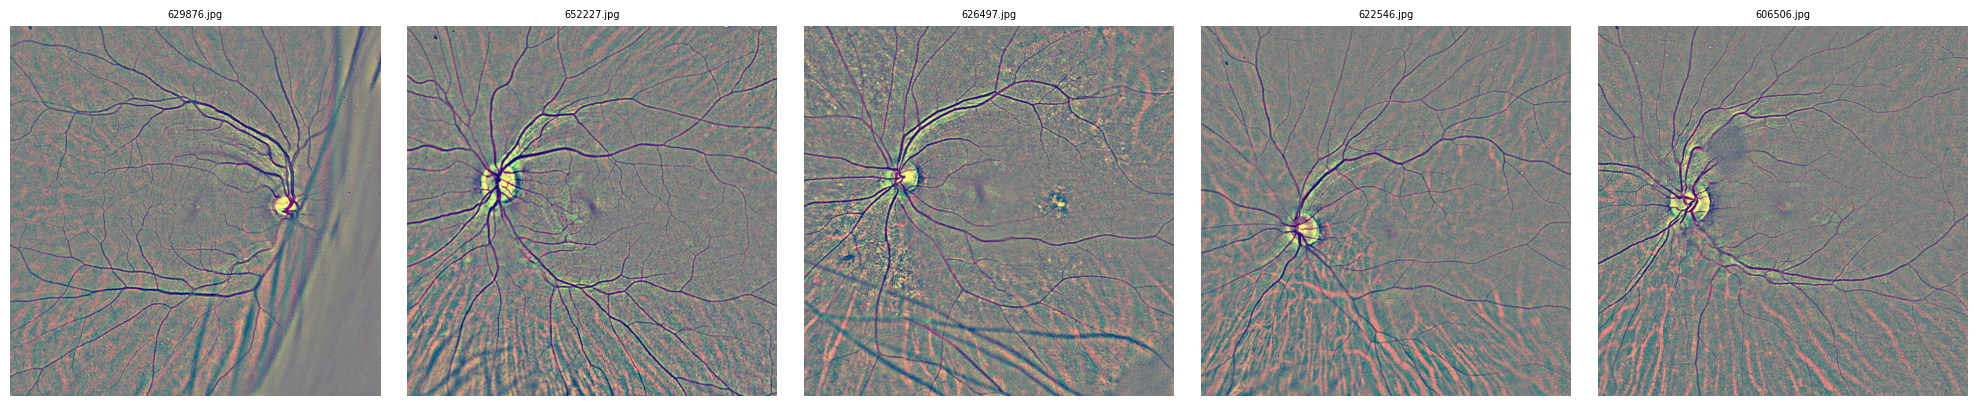

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random

IMG_DIR = "/projects/retprogression/test_cropped1024_wt_10272025"

images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.tif', '.tiff'))]
sample = random.sample(images, min(5, len(images)))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, img_name in zip(axes, sample):
    img = mpimg.imread(os.path.join(IMG_DIR, img_name))
    ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
    ax.set_title(img_name, fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, balanced_accuracy_score, accuracy_score
import numpy as np
import os

# ===========================================================
# Config
# ===========================================================
THRESHOLD = 0.5

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_average.csv",
    },
    # Add more splits here if needed
}

CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")

# ===========================================================
# Run
# ===========================================================
all_results = {}

for split_name, split_cfg in SPLITS.items():
    for subset in ("calibration", "validation"):
        rows = []

        # Individual models
        for i in range(1, 6):
            fp = f"{split_cfg['base']}/predictions_model_{i}_{subset}.csv"
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
            rows.append({"model": f"model_{i}", **compute_all_metrics(yt, yp, THRESHOLD)})

        # Ensemble for this subset
        ensemble_key = f"ensemble_{'cal' if subset == 'calibration' else 'val'}"
        ensemble_fp = split_cfg[ensemble_key]
        if os.path.exists(ensemble_fp):
            yt, yp = load_and_invert(ensemble_fp, corrections=CORRECTIONS)
            rows.append({"model": f"ensemble_avg_{subset}", **compute_all_metrics(yt, yp, THRESHOLD)})
        else:
            print(f"[MISSING] {ensemble_fp}")

        key = f"{split_name} | {subset}"
        all_results[key] = pd.DataFrame(rows).set_index("model")
        print(f"\n=== {key} ===")
        display(all_results[key])

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825

=== test_split | calibration ===


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.8182,0.9963,0.9959,0.8372,0.9072,0.9915,18,800,3,4
model_2,0.9545,0.9726,0.9947,0.6462,0.9636,0.9721,21,781,22,1
model_3,0.9091,0.9801,0.9933,0.6897,0.9446,0.9782,20,787,16,2
model_4,0.8182,0.9813,0.9944,0.6545,0.8998,0.9770,18,788,15,4
model_5,0.9545,0.9851,0.9940,0.7636,0.9698,0.9842,21,791,12,1
ensemble_avg_calibration,0.9545,0.9863,0.9958,0.7778,0.9704,0.9855,21,792,11,1


  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_average.csv] Labels changed: 9 / 826

=== test_split | validation ===


,Sensitivity,Specificity,AUC,F1,Bal_Acc,Accuracy,TP,TN,FP,FN
model,,,,,,,,,,
model_1,0.8824,0.9963,0.9981,0.8571,0.9393,0.9939,15,806,3,2
model_2,1.0000,0.9790,0.9984,0.6667,0.9895,0.9794,17,792,17,0
model_3,1.0000,0.9827,0.9978,0.7083,0.9913,0.9831,17,795,14,0
model_4,1.0000,0.9839,0.9970,0.7234,0.9920,0.9843,17,796,13,0
model_5,1.0000,0.9864,0.9977,0.7556,0.9932,0.9867,17,798,11,0
ensemble_avg_validation,1.0000,0.9889,0.9981,0.7907,0.9944,0.9891,17,800,9,0


Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_average.csv] Labels changed: 11 / 825
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_avg_Test Set 1.png


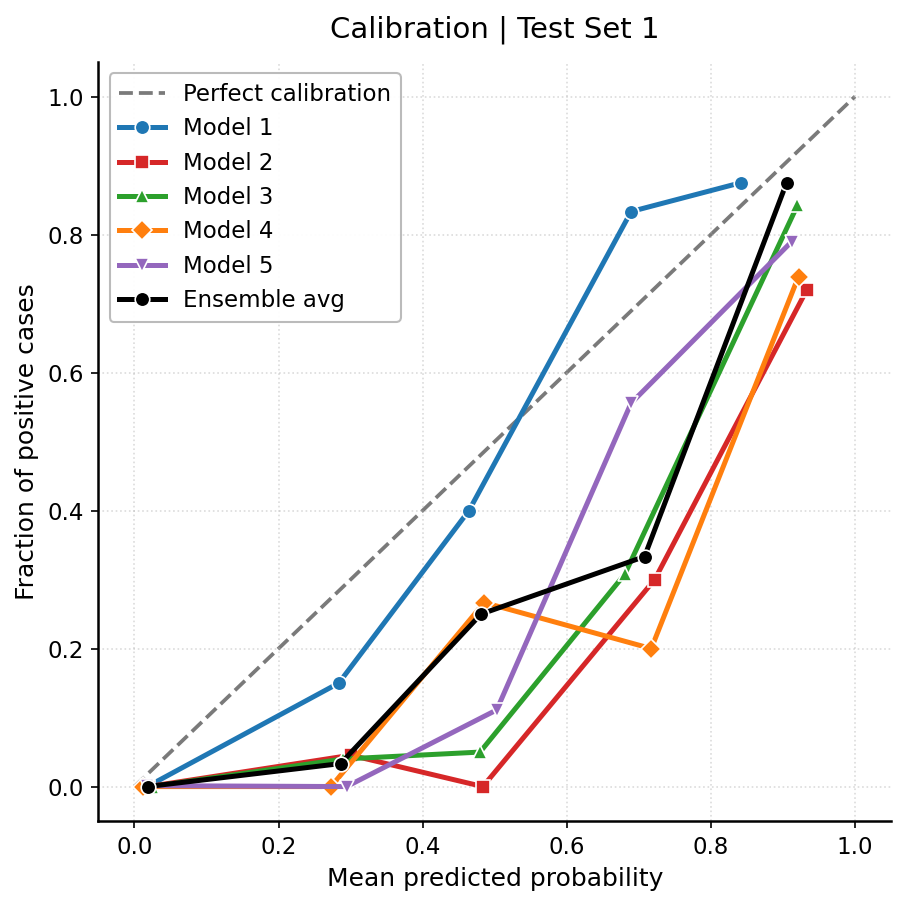

  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_average.csv] Labels changed: 9 / 826
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_avg_Test Set 2.png


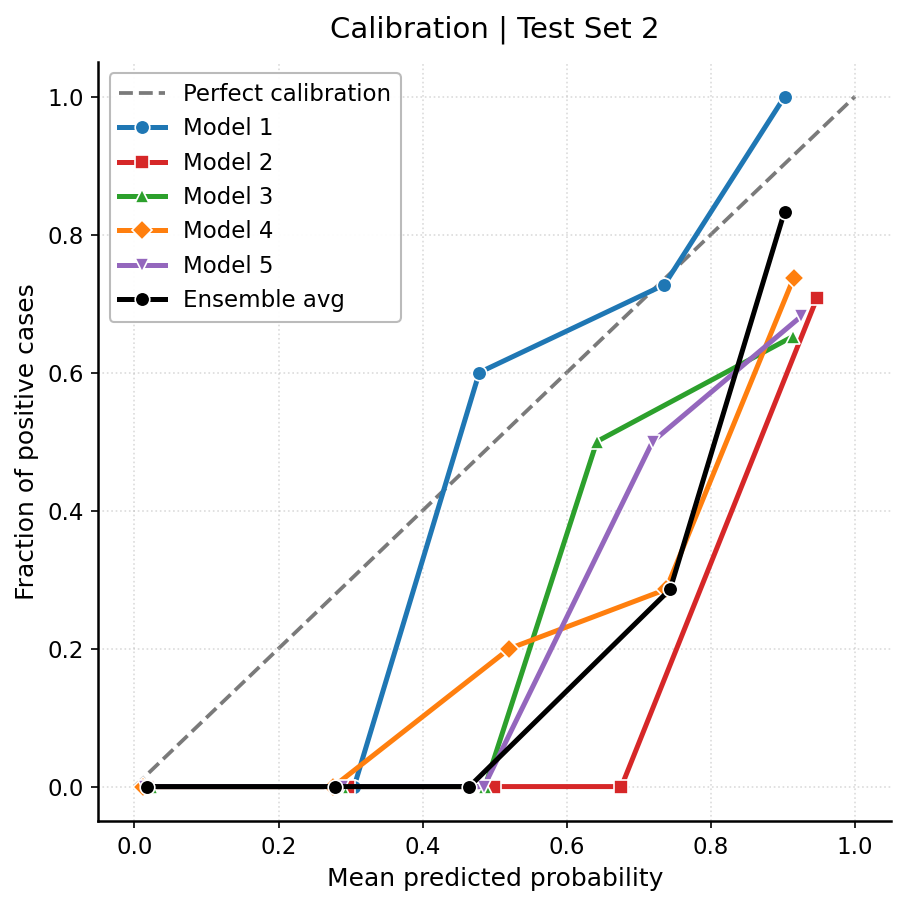

In [22]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

# ===========================================================
# Config
# ===========================================================
THRESHOLD = 0.5
N_BINS    = 5
STRATEGY  = "uniform"
SAVE_DIR  = Path("/projects/retprogression/rgarridogarcia/calibration_plots")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_average.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_average.csv",
    },
}

CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")


# ===========================================================
# Style
# ===========================================================
def _set_publication_style():
    plt.rcParams.update({
        "figure.dpi":           150,
        "savefig.dpi":          600,
        "savefig.bbox":         "tight",
        "savefig.transparent":  False,
        "font.family":          "sans-serif",
        "font.sans-serif":      ["DejaVu Sans", "Arial", "Helvetica"],
        "font.size":            12,
        "axes.titlesize":       14,
        "axes.titleweight":     "normal",
        "axes.labelsize":       12,
        "axes.labelweight":     "normal",
        "axes.linewidth":       1.2,
        "xtick.labelsize":      11,
        "ytick.labelsize":      11,
        "legend.fontsize":      11,
        "legend.frameon":       True,
        "legend.framealpha":    0.95,
        "legend.edgecolor":     "#B8B8B8",
        "axes.spines.top":      False,
        "axes.spines.right":    False,
    })


# ===========================================================
# Calibration plot helpers
# ===========================================================
COLORS = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
MARKERS = ["o", "s", "^", "D", "v"]

def plot_calibration(
    curves: list[dict],   # [{"label": str, "y_true": array, "y_prob": array}, ...]
    title: str,
    save_path: Path | None = None,
    n_bins: int = N_BINS,
    strategy: str = STRATEGY,
    show: bool = True,
):
    """
    Plot calibration curves for multiple models/ensembles on one axes.

    Parameters
    ----------
    curves     : list of dicts with keys "label", "y_true", "y_prob"
    title      : axes title
    save_path  : if given, save figure here
    """
    _set_publication_style()
    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], linestyle="--", color="#7A7A7A",
            linewidth=1.8, label="Perfect calibration", zorder=1)

    for idx, curve in enumerate(curves):
        frac_pos, mean_pred = calibration_curve(
            curve["y_true"], curve["y_prob"],
            n_bins=n_bins, strategy=strategy,
        )
        color = curve.get("color", COLORS[idx % len(COLORS)])
        ax.plot(
            mean_pred, frac_pos,
            marker=MARKERS[idx % len(MARKERS)],
            markersize=7,
            markeredgewidth=0.8,
            markeredgecolor="white",
            color=color,          # <-- was COLORS[idx % len(COLORS)]
            linewidth=2.4,
            label=curve["label"],
            zorder=2 + idx,
        )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positive cases")
    ax.set_title(title, pad=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)
        print(f"[SAVED] {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


# ===========================================================
# Run — one plot per (split, subset) combining models + ensemble
# ===========================================================
for split_name, split_cfg in SPLITS.items():
    for subset in ("calibration", "validation"):

        curves = []

        # Individual models
        for i in range(1, 6):
            fp = f"{split_cfg['base']}/predictions_model_{i}_{subset}.csv"
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
            curves.append({"label": f"Model {i}", "y_true": yt, "y_prob": yp})

        # Ensemble
        ensemble_key = "ensemble_cal" if subset == "calibration" else "ensemble_val"
        ensemble_fp  = split_cfg[ensemble_key]
        if os.path.exists(ensemble_fp):
            yt, yp = load_and_invert(ensemble_fp, corrections=CORRECTIONS)
            curves.append({"label": "Ensemble avg", "y_true": yt, "y_prob": yp, "color": "#000000"})  # ✅ here
        else:
            print(f"[MISSING] {ensemble_fp}")

        if not curves:
            print(f"[SKIP] No data for {split_name} / {subset}")
            continue

        if subset == "calibration":
            test_n = "Test Set 1"
        if subset == "validation":
            test_n = "Test Set 2"
        save_path = SAVE_DIR / split_name / f"calibration_avg_{test_n}.png"
        plot_calibration(
            curves=curves,
            title=f"Calibration | {test_n}",
            save_path=save_path,
            show=True,
        )

Sample correction keys: [605367, 617557, 626306, 629433, 636595]
Key type: <class 'int'>
  [predictions_model_1_calibration.csv] Labels changed: 11 / 825
  [predictions_model_2_calibration.csv] Labels changed: 11 / 825
  [predictions_model_3_calibration.csv] Labels changed: 11 / 825
  [predictions_model_4_calibration.csv] Labels changed: 11 / 825
  [predictions_model_5_calibration.csv] Labels changed: 11 / 825
  [ensemble_logit.csv] Labels changed: 11 / 825
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_logit_Test Set 1.png


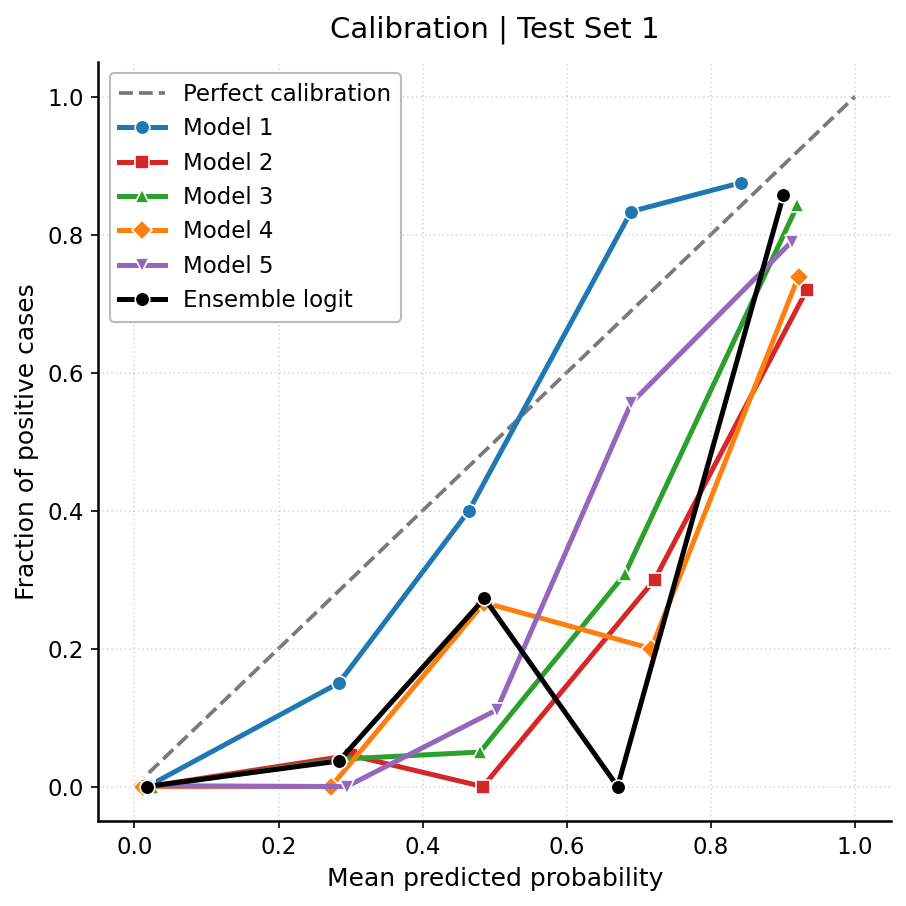

  [predictions_model_1_validation.csv] Labels changed: 9 / 826
  [predictions_model_2_validation.csv] Labels changed: 9 / 826
  [predictions_model_3_validation.csv] Labels changed: 9 / 826
  [predictions_model_4_validation.csv] Labels changed: 9 / 826
  [predictions_model_5_validation.csv] Labels changed: 9 / 826
  [ensemble_logit.csv] Labels changed: 9 / 826
[SAVED] /projects/retprogression/rgarridogarcia/calibration_plots/test_split/calibration_logit_Test Set 2.png


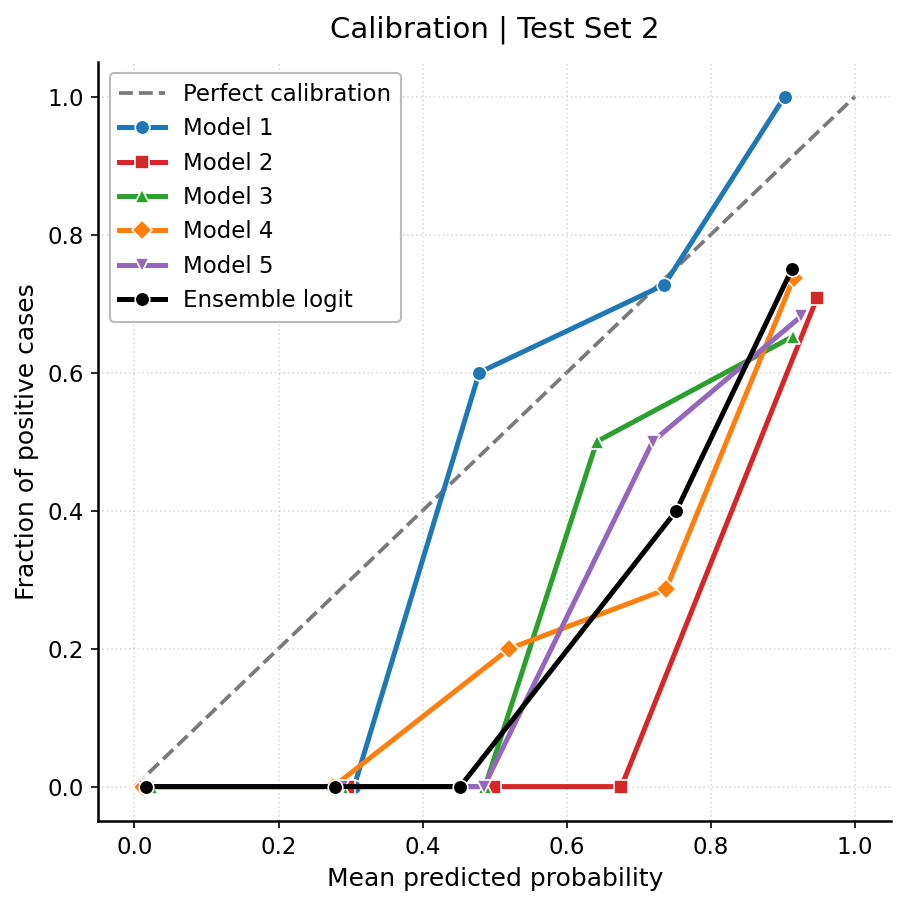

In [23]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

# ===========================================================
# Config
# ===========================================================
THRESHOLD = 0.5
N_BINS    = 5
STRATEGY  = "uniform"
SAVE_DIR  = Path("/projects/retprogression/rgarridogarcia/calibration_plots")

SPLITS = {
    "test_split": {
        "base":         "/projects/retprogression/rgarridogarcia/test_split",
        "ensemble_cal": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_calibration_half_split/ensemble_logit.csv",
        "ensemble_val": "/projects/retprogression/rgarridogarcia/ensemble/ensemble_validation_half_split/ensemble_logit.csv",
    },
}

CORRECTIONS = load_corrections("/projects/retprogression/rgarridogarcia/Gradable_test_relabeling.csv")


# ===========================================================
# Style
# ===========================================================
def _set_publication_style():
    plt.rcParams.update({
        "figure.dpi":           150,
        "savefig.dpi":          600,
        "savefig.bbox":         "tight",
        "savefig.transparent":  False,
        "font.family":          "sans-serif",
        "font.sans-serif":      ["DejaVu Sans", "Arial", "Helvetica"],
        "font.size":            12,
        "axes.titlesize":       14,
        "axes.titleweight":     "normal",
        "axes.labelsize":       12,
        "axes.labelweight":     "normal",
        "axes.linewidth":       1.2,
        "xtick.labelsize":      11,
        "ytick.labelsize":      11,
        "legend.fontsize":      11,
        "legend.frameon":       True,
        "legend.framealpha":    0.95,
        "legend.edgecolor":     "#B8B8B8",
        "axes.spines.top":      False,
        "axes.spines.right":    False,
    })


# ===========================================================
# Calibration plot helpers
# ===========================================================
COLORS = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e", "#9467bd"]
MARKERS = ["o", "s", "^", "D", "v"]

def plot_calibration(
    curves: list[dict],   # [{"label": str, "y_true": array, "y_prob": array}, ...]
    title: str,
    save_path: Path | None = None,
    n_bins: int = N_BINS,
    strategy: str = STRATEGY,
    show: bool = True,
):
    """
    Plot calibration curves for multiple models/ensembles on one axes.

    Parameters
    ----------
    curves     : list of dicts with keys "label", "y_true", "y_prob"
    title      : axes title
    save_path  : if given, save figure here
    """
    _set_publication_style()
    fig, ax = plt.subplots(figsize=(6.2, 6.2))

    # Perfect calibration reference line
    ax.plot([0, 1], [0, 1], linestyle="--", color="#7A7A7A",
            linewidth=1.8, label="Perfect calibration", zorder=1)

    for idx, curve in enumerate(curves):
        frac_pos, mean_pred = calibration_curve(
            curve["y_true"], curve["y_prob"],
            n_bins=n_bins, strategy=strategy,
        )
        color = curve.get("color", COLORS[idx % len(COLORS)])
        ax.plot(
            mean_pred, frac_pos,
            marker=MARKERS[idx % len(MARKERS)],
            markersize=7,
            markeredgewidth=0.8,
            markeredgecolor="white",
            color=color,          # <-- was COLORS[idx % len(COLORS)]
            linewidth=2.4,
            label=curve["label"],
            zorder=2 + idx,
        )

    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positive cases")
    ax.set_title(title, pad=12)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.45)
    ax.legend(loc="upper left")
    fig.tight_layout()

    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path)
        print(f"[SAVED] {save_path}")

    if show:
        plt.show()
    else:
        plt.close(fig)


# ===========================================================
# Run — one plot per (split, subset) combining models + ensemble
# ===========================================================
for split_name, split_cfg in SPLITS.items():
    for subset in ("calibration", "validation"):

        curves = []

        # Individual models
        for i in range(1, 6):
            fp = f"{split_cfg['base']}/predictions_model_{i}_{subset}.csv"
            if not os.path.exists(fp):
                print(f"[MISSING] {fp}")
                continue
            yt, yp = load_and_invert(fp, corrections=CORRECTIONS)
            curves.append({"label": f"Model {i}", "y_true": yt, "y_prob": yp})

        # Ensemble
        ensemble_key = "ensemble_cal" if subset == "calibration" else "ensemble_val"
        ensemble_fp  = split_cfg[ensemble_key]
        if os.path.exists(ensemble_fp):
            yt, yp = load_and_invert(ensemble_fp, corrections=CORRECTIONS)
            curves.append({"label": "Ensemble logit", "y_true": yt, "y_prob": yp, "color": "#000000"})  # ✅ here
        else:
            print(f"[MISSING] {ensemble_fp}")

        if not curves:
            print(f"[SKIP] No data for {split_name} / {subset}")
            continue

        if subset == "calibration":
            test_n = "Test Set 1"
        if subset == "validation":
            test_n = "Test Set 2"
        save_path = SAVE_DIR / split_name / f"calibration_logit_{test_n}.png"
        plot_calibration(
            curves=curves,
            title=f"Calibration | {test_n}",
            save_path=save_path,
            show=True,
        )